Warning message:
“package ‘viridis’ was built under R version 4.3.3”
Loading required package: viridisLite



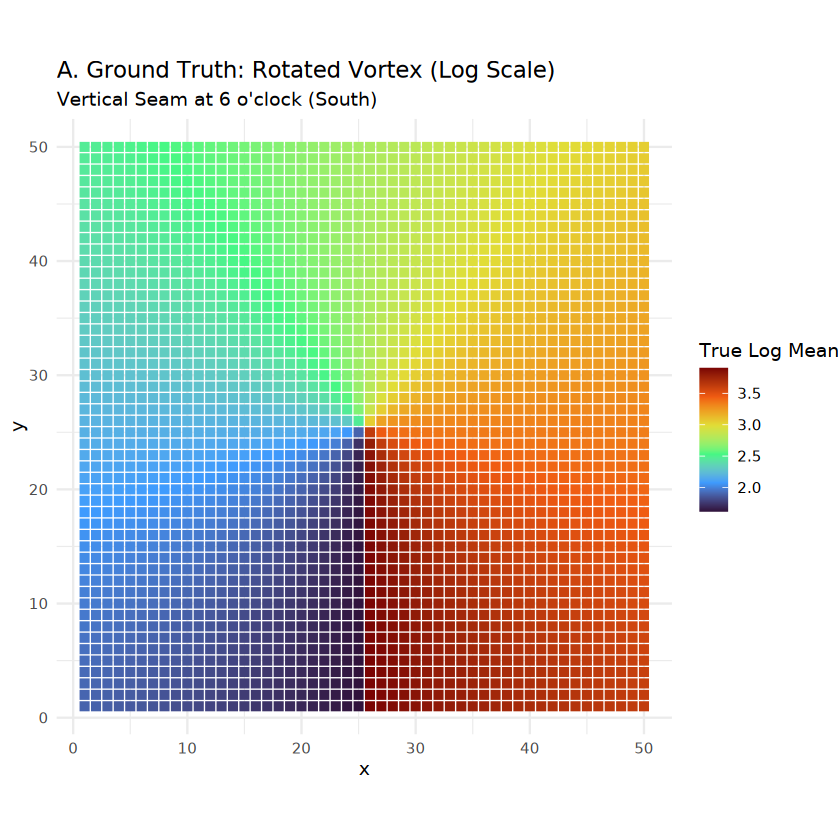

In [1]:
# ==============================================================================
# 0. Generate Synthetic Data (Log Mean is Rotated Vortex)
# ==============================================================================
set.seed(2024)

# 1. Define spatial grid
rows <- 50
cols <- 50
locations <- expand.grid(x = 1:cols, y = 1:rows)
rownames(locations) <- paste0("Spot_", 1:nrow(locations))

# Center point coordinates
cx <- 25.5
cy <- 25.5

# 2. Define angle-based Lambda (rotated 90 degrees)
# The discontinuity seam is located along x = 25.5, y < 25.5 (South / 6 o'clock position)
locations$angle <- atan2(locations$x - cx, locations$y - cy)

# Normalize angle to the interval [0, 1]
locations$norm_angle <- (locations$angle + pi) / (2 * pi)

# 3. Define gene expression intensity (linear variation of log mean along the angle)
base_val <- 5
max_val <- 50

# Linear interpolation in log space
log_lambda_gene1 <- log(base_val) + (log(max_val) - log(base_val)) * locations$norm_angle
lambda_gene1 <- exp(log_lambda_gene1)

log_lambda_gene2 <- log(base_val) + (log(max_val) - log(base_val)) * locations$norm_angle
lambda_gene2 <- exp(log_lambda_gene2)

# 4. Generate count matrix
count_matrix_syn <- matrix(NA, nrow = nrow(locations), ncol = 3)
colnames(count_matrix_syn) <- c("Marker_Vertical", "Marker_Copy", "Control")
rownames(count_matrix_syn) <- rownames(locations)

for(i in 1:nrow(locations)) {
  count_matrix_syn[i, 1] <- rpois(1, lambda = lambda_gene1[i])
  count_matrix_syn[i, 2] <- rpois(1, lambda = lambda_gene2[i])
  count_matrix_syn[i, 3] <- rpois(1, lambda = 10) 
}

count_matrix <- count_matrix_syn
target_genes <- colnames(count_matrix)

# 5. Visualize ground truth (log mean)
library(ggplot2)
library(viridis)

locations$log_val <- log_lambda_gene1

p_truth <- ggplot(locations, aes(x = x, y = y, color = log_val)) +
  geom_point(size = 2.5, shape = 15) +
  scale_color_viridis_c(option = "turbo", name = "True Log Mean") +
  theme_minimal() + coord_fixed() +
  labs(title = "A. Ground Truth: Rotated Vortex (Log Scale)", 
       subtitle = "Vertical Seam at 6 o'clock (South)")

print(p_truth)

Generating 100 signal genes...

Applying Zero-Inflation...

Data generation complete.



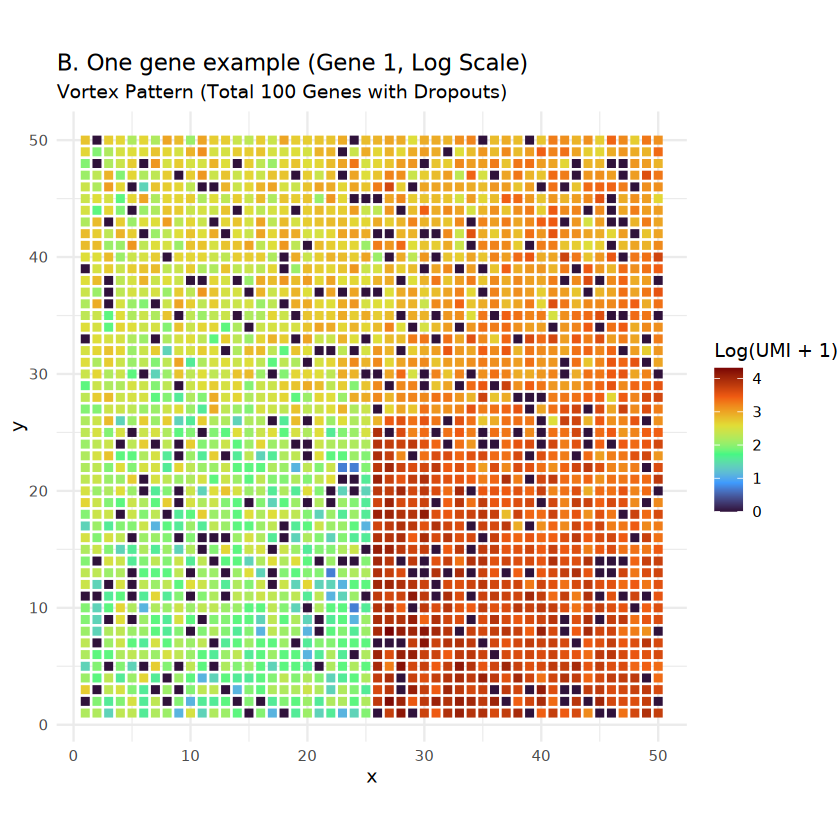

In [2]:
# ==============================================================================
# 1. Generate Synthetic Data (Log Mean Vortex + NB + Zero-Inflation)
# ==============================================================================
set.seed(2024)

# 1. Define spatial grid
rows <- 50; cols <- 50
locations <- expand.grid(x = 1:cols, y = 1:rows)
rownames(locations) <- paste0("Spot_", 1:nrow(locations))
cx <- 25.5; cy <- 25.5

# 2. Define spatial pattern (Vertical Seam / Vortex)
locations$angle <- atan2(locations$x - cx, locations$y - cy)
locations$norm_angle <- (locations$angle + pi) / (2 * pi)

# 3. Construct count matrix with dynamic gene count
n_spots <- nrow(locations)
n_genes <- 100  # <--- Set the desired number of genes here

count_matrix_syn <- matrix(0, nrow = n_spots, ncol = n_genes)
colnames(count_matrix_syn) <- paste0("Signal_Gene_", 1:n_genes)
rownames(count_matrix_syn) <- rownames(locations)

# --- Generate signal genes (spiral gradient in log mean) ---
base_val <- 5; max_val <- 50

# Compute linear interpolation in log space and convert to mean parameter (mu)
log_lambda_signal <- log(base_val) + (log(max_val) - log(base_val)) * locations$norm_angle
lambda_signal <- exp(log_lambda_signal)

message(paste("Generating", n_genes, "signal genes..."))

# Populate columns with negative binomial samples
for(j in 1:n_genes) {
  # size = 100 simulates mild overdispersion (decrease size to e.g., 10 for stronger sequencing noise)
  count_matrix_syn[, j] <- rnbinom(n_spots, mu = lambda_signal, size = 100)
}

# 4. Apply zero-inflation (10% - 20% dropout rate per gene)
message("Applying Zero-Inflation...")
for(j in 1:n_genes) {
  dropout_prob <- runif(1, min = 0.10, max = 0.20)
  is_dropout <- runif(n_spots) < dropout_prob
  count_matrix_syn[is_dropout, j] <- 0
}

count_matrix <- count_matrix_syn
message("Data generation complete.")

# ==============================================================================
# 1. Pre-processing for Algorithms
# ==============================================================================
# Calculate total counts per spot
total_counts <- rowSums(count_matrix)

# Compute global size factors (s)
s <- total_counts / exp(mean(log(total_counts[total_counts > 0])))

# ==============================================================================
# 2. Visualization (Log Scale)
# ==============================================================================
library(ggplot2)

# Extract log-transformed counts for visualization (Gene 1)
locations$val <- log1p(count_matrix[, 1])

p_truth <- ggplot(locations, aes(x = x, y = y, color = val)) +
  geom_point(size = 2.2, shape = 15) +
  scale_color_viridis_c(option = "turbo", name = "Log(UMI + 1)") +
  theme_minimal() + coord_fixed() +
  labs(title = "B. One gene example (Gene 1, Log Scale)", 
       subtitle = paste("Vortex Pattern (Total", n_genes, "Genes with Dropouts)"))

print(p_truth)

Warning message:
“package ‘patchwork’ was built under R version 4.3.3”


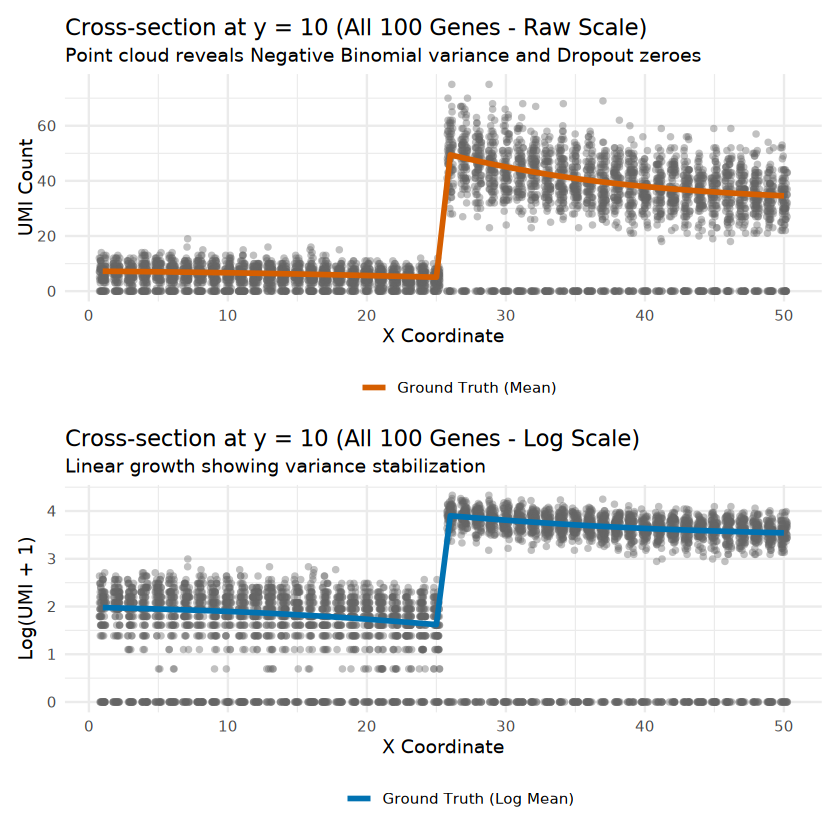

In [3]:
# ==============================================================================
# 2. Visualize Cross-Section: Scatter Point Cloud of All Genes (y = 10)
# ==============================================================================
library(patchwork)
library(ggplot2)

# 1. Extract all spot indices and X coordinates along the row y = 10
idx_y10 <- which(locations$y == 10)
x_coords <- locations$x[idx_y10]

# 2. Prepare ground truth trajectory (shared theoretical mean across all signal genes)
df_line <- data.frame(
  x = x_coords,
  true_lambda = lambda_signal[idx_y10],           # Mean on raw scale
  true_log_lambda = log_lambda_signal[idx_y10]    # Mean on log scale
)

# 3. Extract count data for all signal genes at y = 10 and reshape into long format
# Flatten the submatrix of dimension: length(x_coords) rows x n_genes columns
sim_counts_all <- as.vector(count_matrix[idx_y10, ])

df_points <- data.frame(
  # Replicate X coordinates across all genes to align with flattened counts
  x = rep(x_coords, times = n_genes),
  simulated_count = sim_counts_all,
  log_simulated_count = log1p(sim_counts_all)
)

# 4. Plot on raw count scale
p_raw <- ggplot() +
  # Background: Scatter point cloud for all genes (horizontal jitter applied to reduce overplotting)
  geom_jitter(data = df_points, aes(x = x, y = simulated_count),
              width = 0.25, height = 0, alpha = 0.4, color = "grey40", size = 1.5, shape = 16) +
  # Foreground: Ground truth expected mean curve
  geom_line(data = df_line, aes(x = x, y = true_lambda, color = "Ground Truth (Mean)"), linewidth = 1.2) +
  scale_color_manual(name = "", values = c("Ground Truth (Mean)" = "#D55E00")) +
  theme_minimal() +
  labs(title = paste("Cross-section at y = 10 (All", n_genes, "Genes - Raw Scale)"),
       subtitle = "Point cloud reveals Negative Binomial variance and Dropout zeroes",
       x = "X Coordinate", y = "UMI Count") +
  theme(legend.position = "bottom")

# 5. Plot on log-transformed scale (log1p)
p_log <- ggplot() +
  # Background: Log-transformed count point cloud
  geom_jitter(data = df_points, aes(x = x, y = log_simulated_count),
              width = 0.25, height = 0, alpha = 0.4, color = "grey40", size = 1.5, shape = 16) +
  # Foreground: Ground truth log-mean trajectory
  geom_line(data = df_line, aes(x = x, y = true_log_lambda, color = "Ground Truth (Log Mean)"), linewidth = 1.2) +
  scale_color_manual(name = "", values = c("Ground Truth (Log Mean)" = "#0072B2")) +
  theme_minimal() +
  labs(title = paste("Cross-section at y = 10 (All", n_genes, "Genes - Log Scale)"),
       subtitle = "Linear growth showing variance stabilization",
       x = "X Coordinate", y = "Log(UMI + 1)") +
  theme(legend.position = "bottom")

# 6. Assemble and display multi-panel layout
print(p_raw / p_log)


--- Running Pure 1D C++ RJ-MCMC ---

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


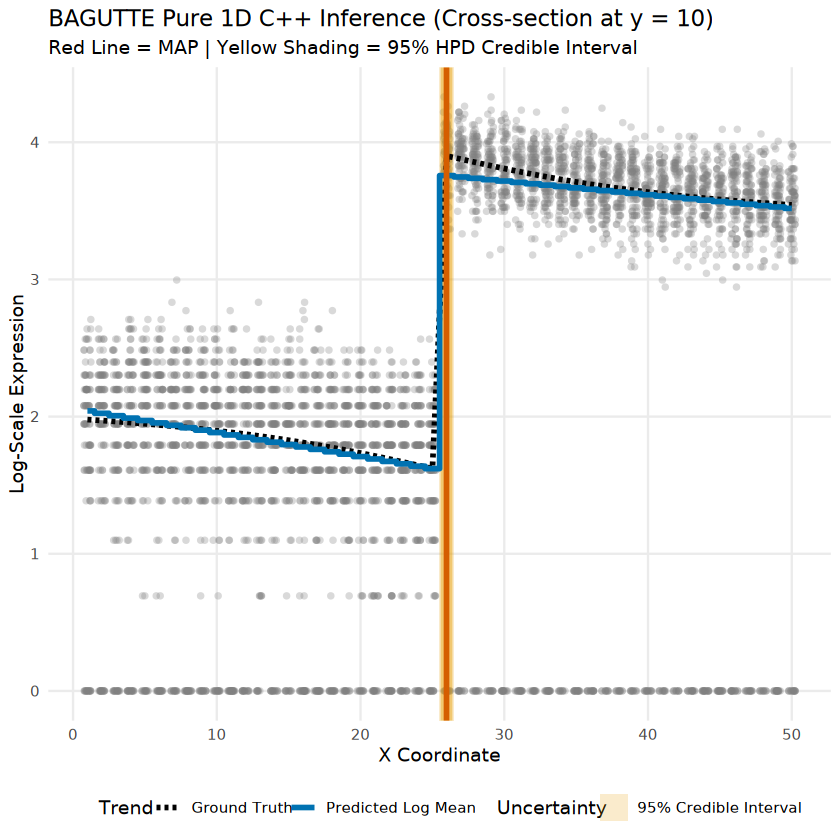

In [4]:
# ==============================================================================
# 1. Prepare and Compile C++ Core Implementation
# ==============================================================================
library(Rcpp)
library(RcppArmadillo)
library(ggplot2)

# Set the absolute file path to the C++ source implementation
cpp_file_path <- "../script/BAGETI.cpp"
sourceCpp(cpp_file_path)

# ==============================================================================
# 2. Extract 1D Cross-Sectional Slice (y = 10)
# ==============================================================================
idx_y10 <- which(locations$y == 10)
loc_x <- locations$x[idx_y10]

# Subsample count matrix (dim: N_spots x G_genes)
counts_1d <- as.matrix(count_matrix[idx_y10, , drop = FALSE])
n_genes_current <- ncol(counts_1d)

# Assign all genes to a single shared cluster
gene_clusters <- rep(1L, n_genes_current)
s_1d <- rep(1.0, length(idx_y10))

# ==============================================================================
# 3. Execute 1D C++ Reversible Jump MCMC (RJ-MCMC) Sampler
# ==============================================================================
message("\n--- Running Pure 1D C++ RJ-MCMC ---")

res_1d_cpp <- rjmcmc_single_line_with_neighbors(
  x = loc_x, 
  y = counts_1d, 
  gene_clusters = gene_clusters, 
  s_ = s_1d, 
  cp_init = NULL,                # Cold-start initialization
  neighbor_cp_states = list(),   # Independent 1D slice without neighborhood spatial priors
  n_iter = 3000, 
  burnin = 500, 
  cp_distance = 2,               # Minimum distance threshold between adjacent change-points
  lambda = 2.0                   # Prior expected number of change-points (Poisson hyperparameter)
)

# ==============================================================================
# 4. Parse Posterior Chains and Compute 95% Credible Interval
# ==============================================================================
# 1. Compute change-point marginal posterior inclusion probabilities
cp_mat <- res_1d_cpp$cp_indicator[, 1, ]
cp_posterior <- rowMeans(cp_mat)

# Extract maximum a posteriori (MAP) change-point location
map_cp_idx <- which(cp_posterior == max(cp_posterior) & cp_posterior > 0.5)
map_cp_x <- loc_x[map_cp_idx]

# ------------------------------------------------------------------------------
# Construct 95% Highest Posterior Density (HPD) Credible Interval
# Cumulatively sum posterior probabilities from highest to lowest until 95% mass is spanned
# ------------------------------------------------------------------------------
# Normalize probabilities under single change-point assumption
prob_normalized <- cp_posterior / sum(cp_posterior)

# Rank indices in descending order of posterior probability
sorted_idx <- order(prob_normalized, decreasing = TRUE)
cum_prob <- cumsum(prob_normalized[sorted_idx])

# Identify indices covering up to 95% of cumulative probability mass
ci_indices <- sorted_idx[cum_prob <= 0.95]
# Ensure MAP point inclusion if probability mass is highly concentrated (> 95% at mode)
if(length(ci_indices) == 0) ci_indices <- sorted_idx[1] 
# Include boundary point crossing the 0.95 threshold to guarantee full coverage
if(cum_prob[length(ci_indices)] < 0.95 && length(ci_indices) < length(sorted_idx)){
  ci_indices <- c(ci_indices, sorted_idx[length(ci_indices) + 1])
}

# Determine spatial coordinate bounds for the credible interval
ci_lower <- min(loc_x[ci_indices], na.rm = TRUE)
ci_upper <- max(loc_x[ci_indices], na.rm = TRUE)

df_ci_bounds <- data.frame(
  xmin = ci_lower - 0.5, # Extend boundary by half-spot width for visual region enclosure
  xmax = ci_upper + 0.5,
  ymin = -Inf, 
  ymax = Inf
)
# ------------------------------------------------------------------------------

# 2. Extract predicted log-mean expression parameters
pred_intercept <- rowMeans(res_1d_cpp$intercept[1, , ])
pred_slope <- rowMeans(res_1d_cpp$beta[1, , ])
pred_log_mean <- pred_intercept + pred_slope * loc_x

df_lines <- data.frame(
  x = loc_x,
  true_log_lambda = log_lambda_signal[idx_y10], 
  pred_log_mean = pred_log_mean,                
  prob = cp_posterior                           
)

sim_counts_all <- as.vector(counts_1d)
df_points <- data.frame(
  x = rep(loc_x, times = n_genes_current),
  log_simulated_count = log1p(sim_counts_all)
)

# ==============================================================================
# 5. Visualization with 95% Credible Interval
# ==============================================================================
p_1d <- ggplot() +
  # 1. 95% HPD Credible Interval shaded rectangle
  geom_rect(data = df_ci_bounds, aes(xmin = xmin, xmax = xmax, ymin = ymin, ymax = ymax, fill = "95% Credible Interval"),
            alpha = 0.2) +
            
  # 2. Observed gene expression scatter point cloud
  geom_jitter(data = df_points, aes(x = x, y = log_simulated_count),
              width = 0.25, height = 0, alpha = 0.3, color = "grey50", size = 1.5, shape = 16) +
  
  # 3. Posterior inclusion probability vertical density bands
  geom_vline(data = df_lines[df_lines$prob > 0.02, ], 
             aes(xintercept = x, alpha = prob), 
             color = "#E69F00", size = 2.5) +
  scale_alpha_continuous(range = c(0.1, 0.8), guide = "none") +
  
  # 4. Ground truth trajectory vs. estimated segment mean
  geom_line(data = df_lines, aes(x = x, y = true_log_lambda, color = "Ground Truth"), 
            linetype = "dashed", linewidth = 1.2) +
  geom_step(data = df_lines, aes(x = x, y = pred_log_mean, color = "Predicted Log Mean"), 
            linewidth = 1.2, direction = "mid") +
  
  # 5. Maximum a posteriori (MAP) change-point estimate
  geom_vline(xintercept = map_cp_x, color = "#D55E00", linetype = "solid", size = 1.2) +
  
  # Styling and legend configuration
  scale_color_manual(name = "Trend", values = c("Ground Truth" = "black", "Predicted Log Mean" = "#0072B2")) +
  scale_fill_manual(name = "Uncertainty", values = c("95% Credible Interval" = "#E69F00")) +
  theme_minimal() +
  labs(title = "BAGUTTE Pure 1D C++ Inference (Cross-section at y = 10)",
       subtitle = "Red Line = MAP | Yellow Shading = 95% HPD Credible Interval",
       x = "X Coordinate", y = "Log-Scale Expression") +
  theme(legend.position = "bottom", panel.grid.minor = element_blank())

print(p_1d)

In [5]:
# ==============================================================================
# 1. Environment Initialization & Path Configuration (Absolute HPC Paths)
# ==============================================================================
message("\n--- Initializing BAGUTTE Module-Level 2D Inference ---")

# Source core R wrapper and specify C++ source file path on the cluster
source("../script/BAGUTTE_main.R")

# Load required packages for plotting, vector fields, and spatial geometries
library(ggplot2); library(ggquiver); library(viridis)
library(sf); library(concaveman)

# Extract gene targets and prepare spatial coordinates matrix
target_genes <- colnames(count_matrix)
gene_number_sub <- 1:ncol(count_matrix)
loc_clean <- as.matrix(locations[, c("x", "y")])
s <- 1

# ==============================================================================
# 2. Core Inference: Multi-Directional Scanning (Column/X and Row/Y)
# ==============================================================================
directions <- c("col", "row")
results_store <- list()

for (d in directions) {
  message(sprintf("\n>>> Running BAGUTTE in direction: %s ...", d))
  
  res <- tryCatch({
    test_coefficient_multiple_mrf(
      count = count_matrix, 
      gene_number = gene_number_sub, 
      manual_s = s,
      cp_distance = 20,
      loc = loc_clean,
      direction = d, 
      cpp_file = cpp_file,
      n_chains = 2, n_iter = 3000, burnin = 500, n_rb_cycles = 5,
      lambda = 1.0, mrf_alpha = 2, mrf_beta = 1, 
      mrf_bandwidth = 2, 
      cluster = list(cluster_labels_origin = rep(1, length(gene_number_sub)), 
                     cluster_labels = rep(1L, length(gene_number_sub))), 
      n_cores = 60
    )
  }, error = function(e) {
    message(paste("Error in direction", d, ":", e$message)); return(NULL)
  })
  results_store[[d]] <- res
}


--- Initializing BAGUTTE Module-Level 2D Inference ---

Warning message:
“package ‘doParallel’ was built under R version 4.3.3”
Loading required package: foreach

Warning message:
“package ‘foreach’ was built under R version 4.3.3”
Loading required package: iterators

Warning message:
“package ‘iterators’ was built under R version 4.3.3”
Loading required package: parallel

Warning message:
“package ‘sf’ was built under R version 4.3.2”
Linking to GEOS 3.12.0, GDAL 3.8.0, PROJ 9.3.0; sf_use_s2() is TRUE

Warning message:
“package ‘concaveman’ was built under R version 4.3.3”

>>> Running BAGUTTE in direction: col ...

Using user-provided size factors.

Found 50 lines (segments) in direction 'col'

Red-Black Assignment (Inherited): 25 Red, 25 Black segments.


========== Red-Black Cycle 1/5 ==========

Updating RED lines (25 lines)...

Updating BLACK lines (25 lines)...

Completed cycle 1


========== Red-Black Cycle 2/5 ==========

Updating RED lines (25 lines)...

Updating BLACK lines

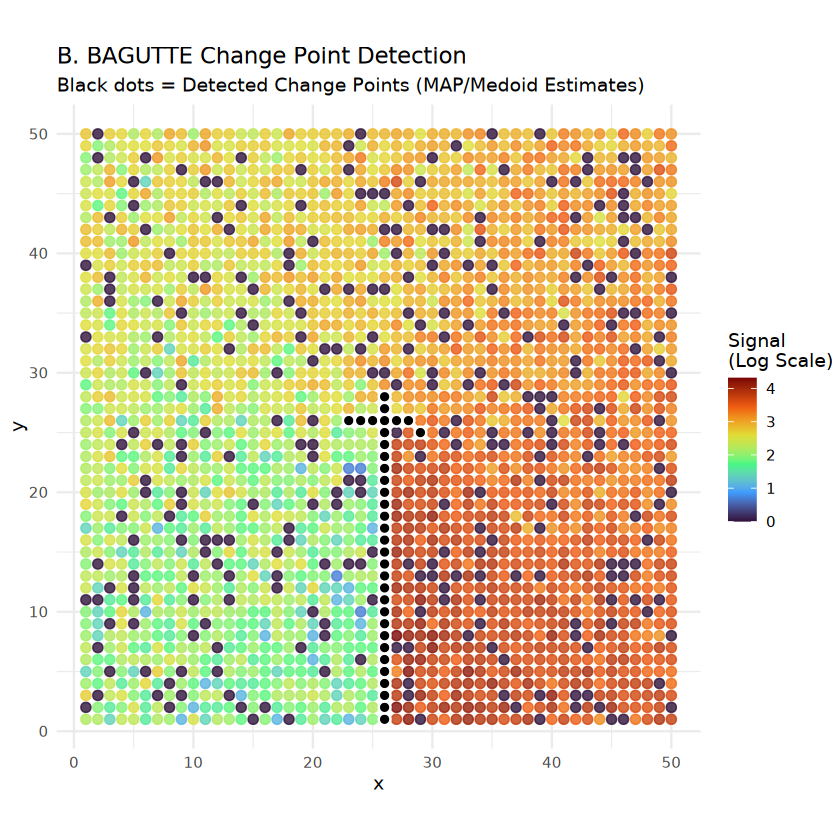

In [6]:
# ==============================================================================
# 3. Extract Change-Point Indices (Using Built-in cp_matrix)
# ==============================================================================
cp_indices <- c()

# Iterate across scanning directions (e.g., row, col) to collect detected global CP indices
for (d in names(results_store)) {
  res <- results_store[[d]]
  if (!is.null(res) && !is.null(res$cp_matrix)) {
    # Extract change points for Cluster 1 (all signal genes assigned to Cluster 1)
    idx <- which(res$cp_matrix[, 1] == 1)
    cp_indices <- c(cp_indices, idx)
  }
}

# Deduplicate indices in case horizontal and vertical scans detect identical spots
cp_indices <- unique(cp_indices)

if (length(cp_indices) > 0) {
  df_cp <- data.frame(
    x = locations$x[cp_indices],
    y = locations$y[cp_indices]
  )
} else {
  df_cp <- data.frame(x = numeric(), y = numeric())
  message("Warning: No change points detected by BAGUTTE.")
}

# ==============================================================================
# 4. Final Comparison & Visualization (Change-Point Overlay)
# ==============================================================================
library(patchwork)
library(ggplot2)

# 1. Set background baseline expression (log-scale spiral gradient for visualization)
locations$val <- log1p(count_matrix[, 1]) 

# 2. Plot spatial expression field with discrete change-point overlays
p_bagutte <- ggplot() +
  # Background: True expression intensity gradient
  geom_point(data = locations, aes(x = x, y = y, color = val), size = 2.2, alpha = 0.8) + 
  scale_color_viridis_c(option = "turbo", name = "Signal\n(Log Scale)") +
  
  # Foreground: Highlight detected change-point spots without trajectory lines
  geom_point(data = df_cp, aes(x = x, y = y), 
             fill = "black", color = "white", shape = 21, size = 2.5, stroke = 0.8) +
  
  theme_minimal() + coord_fixed() +
  labs(title = "B. BAGUTTE Change Point Detection", 
       subtitle = "Black dots = Detected Change Points (MAP/Medoid Estimates)")

print(p_bagutte)

# (Optional) Benchmark comparison against BayesSpace spatial clustering
if (exists("df_bayes")) {
  p_bayes <- ggplot(df_bayes, aes(x = x, y = y, color = cluster)) +
    geom_point(size = 2, shape = 15) +
    scale_color_brewer(palette = "Set1") +
    theme_minimal() + coord_fixed() +
    labs(title = "C. BayesSpace", subtitle = paste("Using", ncol(count_matrix), "Signal Genes"))
  
  print(p_bagutte + p_bayes)
}

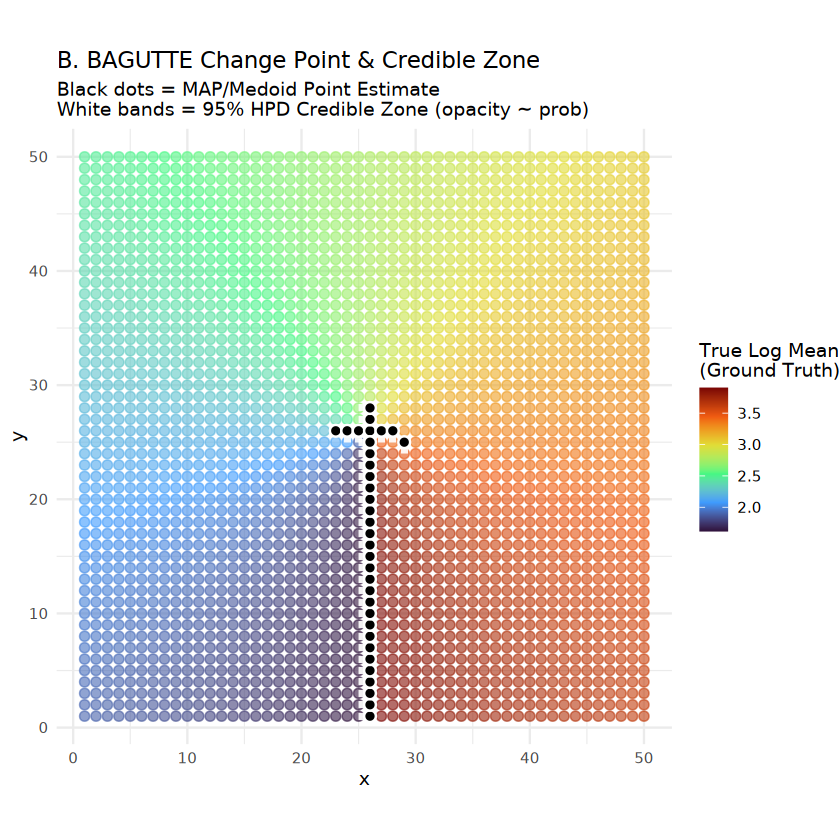

In [7]:
# ==============================================================================
# 3. Extract Change-Point and Credible Zone (HPD CI) Data
# ==============================================================================
cp_indices <- c()
ci_edges_list <- list()

for (d in names(results_store)) {
  res <- results_store[[d]]
  if (is.null(res) || is.null(res$line_results)) next
  
  # Extract point estimates (Change Points)
  if (!is.null(res$cp_matrix)) {
    idx <- which(res$cp_matrix[, 1] == 1)
    cp_indices <- c(cp_indices, idx)
  }
  
  # Extract Credible Zone (CI Edges)
  for (line_res in res$line_results) {
    if (is.null(line_res)) next
    cp_details <- line_res$final_cp_details[[1]]$details
    
    if (length(cp_details) > 0) {
      for (edg in cp_details) {
        ci_mat <- edg$ci_edges_global
        if (is.null(ci_mat) || nrow(ci_mat) == 0) next
        
        # Iterate over all candidate edges within the credible interval
        for (k in 1:nrow(ci_mat)) {
          n1 <- ci_mat[k, 1]
          n2 <- ci_mat[k, 2]
          prob <- edg$ci_probs[k] # Retrieve the posterior probability for this edge
          
          ci_edges_list[[length(ci_edges_list) + 1]] <- data.frame(
            x = locations$x[n1], y = locations$y[n1],
            xend = locations$x[n2], yend = locations$y[n2],
            direction = d,
            prob = prob
          )
        }
      }
    }
  }
}

# Deduplicate optimal change-point indices
cp_indices <- unique(cp_indices)
if (length(cp_indices) > 0) {
  df_cp <- data.frame(x = locations$x[cp_indices], y = locations$y[cp_indices])
} else {
  df_cp <- data.frame(x = numeric(), y = numeric())
}

# Construct Credible Zone data frame
if (length(ci_edges_list) > 0) {
  df_ci <- do.call(rbind, ci_edges_list)
} else {
  df_ci <- data.frame(x = numeric(), y = numeric(), xend = numeric(), yend = numeric(), prob = numeric())
}


# ==============================================================================
# 4. Final Comparison & Visualization (Change Points + Credible Zone)
# ==============================================================================
library(patchwork)
library(ggplot2)

# 1. Set baseline expression (using Ground Truth log-mean)
locations$val <- log_lambda_signal 

# 2. Generate visualization plot
p_bagutte <- ggplot() +
  # Layer 1: Background, true smooth expression gradient (Ground Truth)
  geom_point(data = locations, aes(x = x, y = y, color = val), size = 2.2, alpha = 0.6) + 
  scale_color_viridis_c(option = "turbo", name = "True Log Mean\n(Ground Truth)") +
  
  # Layer 2: Credible Zone (Candidate boundary segments within 95% HPD CI)
  # Connect candidate edges using segments with alpha mapped to posterior probability
  geom_segment(data = df_ci, aes(x = x, y = y, xend = xend, yend = yend, alpha = prob), 
               color = "white", linewidth = 1.5) +
  scale_alpha_continuous(range = c(0.1, 0.9), guide = "none") + # Higher posterior probability yields higher opacity
  
  # Layer 3: Foreground (Spots), highlighting MAP/medoid change-point estimates
  geom_point(data = df_cp, aes(x = x, y = y), 
             fill = "black", color = "white", shape = 21, size = 2.5, stroke = 0.8) +
  
  theme_minimal() + coord_fixed() +
  labs(title = "B. BAGUTTE Change Point & Credible Zone", 
       subtitle = "Black dots = MAP/Medoid Point Estimate\nWhite bands = 95% HPD Credible Zone (opacity ~ prob)")

print(p_bagutte)

# (Optional) Benchmark comparison against BayesSpace spatial clustering
if (exists("df_bayes")) {
  p_bayes <- ggplot(df_bayes, aes(x = x, y = y, color = cluster)) +
    geom_point(size = 2, shape = 15) +
    scale_color_brewer(palette = "Set1") +
    theme_minimal() + coord_fixed() +
    labs(title = "C. BayesSpace", subtitle = paste("Using", ncol(count_matrix), "Signal Genes"))
  
  print(p_bagutte + p_bayes)
}


--- Synthesizing Vector Field + Smoothing + Plotting ---

Vector field constructed using 2500 spatial locations.

Performing spatial smoothing and plotting...

>>> [Success] Plot saved to BAGUTTE_Corrected_VectorField_100G_Normalized.png <<<



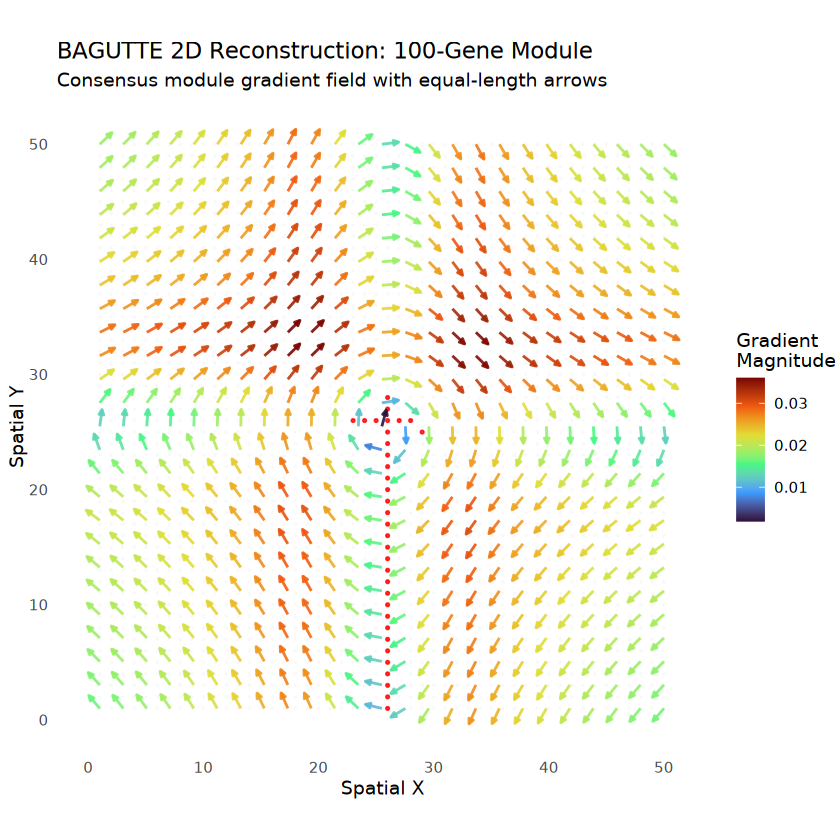

In [8]:
# ==============================================================================
# 4. Synthesize Module-Level Vector Field + Spatial Smoothing + Plotting
# ==============================================================================
message("\n--- Synthesizing Vector Field + Smoothing + Plotting ---")

res_col <- results_store[["col"]]   # Column direction corresponds to the original Y-axis gradient
res_row <- results_store[["row"]]   # Row direction corresponds to the original X-axis gradient

if (!is.null(res_col) && !is.null(res_row)) {

  n_genes <- length(target_genes)

  # ---------------------------------------------------------------------------
  # 3. Construct the 2D module-level consensus gradient field
  #
  # The row-direction fit estimates the gradient along the original X axis,
  # whereas the column-direction fit estimates the gradient along the original Y axis.
  #
  # For the multi-gene module, gene-specific slopes are averaged at each spatial
  # location to obtain a consensus spatial gradient vector.
  # ---------------------------------------------------------------------------

  beta_x <- rowMeans(
    res_row$slope_loc[, 3:(2 + n_genes), drop = FALSE],
    na.rm = TRUE
  )

  beta_y <- rowMeans(
    res_col$slope_loc[, 3:(2 + n_genes), drop = FALSE],
    na.rm = TRUE
  )

  # Combine the two orthogonal directional components into a 2D vector field
  df_vf <- data.frame(
    x  = res_col$slope_loc[, 1],
    y  = res_col$slope_loc[, 2],
    dx = beta_x,
    dy = beta_y,

    # Mark spots detected as change points in either spatial direction
    is_cp = (
      res_col$cp_matrix[, 1] == 1 |
      res_row$cp_matrix[, 1] == 1
    )
  )

  # Remove incomplete observations
  df_vf <- na.omit(df_vf)

  # Compute the magnitude of the raw consensus gradient vector
  df_vf$mag <- sqrt(df_vf$dx^2 + df_vf$dy^2)

  message(
    sprintf(
      "Vector field constructed using %d spatial locations.",
      nrow(df_vf)
    )
  )

  # ---------------------------------------------------------------------------
  # 4. Spatial smoothing of the vector field
  # ---------------------------------------------------------------------------
  message("Performing spatial smoothing and plotting...")

  # Smooth the X- and Y-direction gradient components independently
  fit_dx <- loess(
    dx ~ x + y,
    data = df_vf,
    span = 0.12,
    degree = 2
  )

  fit_dy <- loess(
    dy ~ x + y,
    data = df_vf,
    span = 0.12,
    degree = 2
  )

  # Use a relatively sparse grid to provide sufficient spacing between arrows
  grid_size <- 25

  gx <- seq(
    min(df_vf$x),
    max(df_vf$x),
    length.out = grid_size
  )

  gy <- seq(
    min(df_vf$y),
    max(df_vf$y),
    length.out = grid_size
  )

  grid_df <- expand.grid(
    x = gx,
    y = gy
  )

  # Predict the smoothed gradient components on the regular spatial grid
  grid_df$dx <- as.vector(
    predict(fit_dx, newdata = grid_df)
  )

  grid_df$dy <- as.vector(
    predict(fit_dy, newdata = grid_df)
  )

  # Compute the magnitude of the smoothed gradient vectors
  grid_df$mag <- sqrt(
    grid_df$dx^2 +
    grid_df$dy^2
  )

  # Remove undefined, infinite, and effectively zero-length vectors
  # before unit-vector normalization
  grid_df <- grid_df[
    is.finite(grid_df$dx) &
    is.finite(grid_df$dy) &
    is.finite(grid_df$mag) &
    grid_df$mag > 1e-8,
  ]

  # ---------------------------------------------------------------------------
  # Restrict the vector field to the tissue region
  # ---------------------------------------------------------------------------

  # Construct a concave hull from observed spatial locations
  pts_sf <- st_as_sf(
    df_vf,
    coords = c("x", "y")
  )

  hull <- concaveman(
    pts_sf,
    concavity = 2
  )

  hull_coords <- st_coordinates(hull)

  # Retain only grid points located inside the tissue boundary
  in_tissue <- sp::point.in.polygon(
    grid_df$x,
    grid_df$y,
    hull_coords[, 1],
    hull_coords[, 2]
  )

  grid_df <- grid_df[
    in_tissue > 0,
  ]

  # ---------------------------------------------------------------------------
  # Normalize vectors to equal arrow length
  #
  # Arrow direction represents the direction of the consensus gradient.
  # Arrow color represents the original gradient magnitude.
  # ---------------------------------------------------------------------------

  # Estimate spatial spacing between adjacent grid points
  step_size_x <- (
    max(df_vf$x) - min(df_vf$x)
  ) / grid_size

  step_size_y <- (
    max(df_vf$y) - min(df_vf$y)
  ) / grid_size

  # Use the smaller spacing to avoid arrow overlap
  step_size <- min(
    step_size_x,
    step_size_y
  )

  # Set displayed arrow length to 75% of the grid spacing
  scale_factor <- step_size * 0.75

  # Convert each smoothed gradient vector to a unit vector
  grid_df$dx_norm <- grid_df$dx / grid_df$mag
  grid_df$dy_norm <- grid_df$dy / grid_df$mag

  # Compute arrow endpoints
  grid_df$xend <- (
    grid_df$x +
    grid_df$dx_norm * scale_factor
  )

  grid_df$yend <- (
    grid_df$y +
    grid_df$dy_norm * scale_factor
  )

  # ---------------------------------------------------------------------------
  # Final visualization
  # ---------------------------------------------------------------------------

  p_final <- ggplot() +

    # Display all observed spatial locations in the background
    geom_point(
      data = df_vf,
      aes(x = x, y = y),
      color = "grey92",
      size = 0.1,
      alpha = 0.2
    ) +

    # Highlight BAGUTTE-detected change-point locations
    geom_point(
      data = subset(df_vf, is_cp),
      aes(x = x, y = y),
      color = "red",
      size = 0.4,
      alpha = 0.8
    ) +

    # Draw equal-length arrows.
    # Direction represents the consensus gradient direction,
    # while color represents the gradient magnitude.
    geom_segment(
      data = grid_df,
      aes(
        x = x,
        y = y,
        xend = xend,
        yend = yend,
        color = mag
      ),
      arrow = arrow(
        length = unit(0.12, "cm"),
        type = "closed",
        angle = 25
      ),
      linewidth = 0.6,
      alpha = 0.9
    ) +

    scale_color_viridis_c(
      option = "turbo",
      name = "Gradient\nMagnitude"
    ) +

    coord_fixed() +
    theme_minimal() +

    labs(
      title = "BAGUTTE 2D Reconstruction: 100-Gene Module",
      subtitle = "Consensus module gradient field with equal-length arrows",
      x = "Spatial X",
      y = "Spatial Y"
    ) +

    theme(
      panel.grid = element_blank(),
      panel.background = element_rect(
        fill = "white",
        color = NA
      )
    )

  # Save the final figure
  ggsave(
    "BAGUTTE_Corrected_VectorField_100G_Normalized.png",
    p_final,
    width = 10,
    height = 8,
    dpi = 300
  )

  print(p_final)

  message(
    ">>> [Success] Plot saved to BAGUTTE_Corrected_VectorField_100G_Normalized.png <<<"
  )

} else {

  stop(
    "results_store[['row']] or results_store[['col']] is NULL."
  )
}